# 🦅 A Qiskit on IBM Heron Tutorial

A single-notebook walkthrough of the Qiskit "hello world" workflow, run against a real IBM **Heron R2** QPU (or a local simulator).

Adapted from IBM's [*Use a quantum computer today*](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today) course.

### What you'll do
1. **Set up** Qiskit and the IBM Runtime client.
2. Build a **Bell state** — the smallest interesting entangled circuit (2 qubits).
3. **Transpile and run** it on hardware via the `SamplerV2` primitive.
4. **Scale up** the same idea to a **40-qubit GHZ state**, built with a clever *logarithmic-depth* circuit so it survives on real hardware — and simulate it efficiently as a Clifford circuit.

### The one idea to take away
A Hadamard gate creates a *superposition*; a CNOT *spreads* it. Chain those two primitives and you can put **any number of qubits** into a single shared coin-flip: every shot collapses to *all-zeros* or *all-ones*, never anything in between. That correlation — measuring one qubit instantly fixes the rest — is entanglement, and it's the raw material of quantum computing.

> **Prerequisites:** an IBM Quantum account and API key (see `.env.example`). The simulator path needs no account.

## 1. Setup & Imports

We pull in three layers of the stack:

- **`qiskit`** — build and visualize circuits (`QuantumCircuit`, `plot_histogram`).
- **`qiskit-aer`** — the local high-performance simulator, used both as a stand-in for hardware and (later) as an efficient *Clifford* simulator for the 40-qubit circuit.
- **`qiskit-ibm-runtime`** — the cloud client: `QiskitRuntimeService` (auth + backend discovery) and `SamplerV2`, the primitive that submits circuits and returns measurement counts.

The transpiler's `generate_preset_pass_manager` rewrites a circuit into the **ISA** (the native gates and qubit connectivity) of whichever backend we target. Running the cell also prints versions, so the notebook is reproducible.

In [1]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

# System
import os
import sys
from dotenv import load_dotenv

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.13
qiskit: 2.4.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.47.0


## 2. The Bell State

The Bell state is the "hello world" of entanglement: two qubits in the maximally entangled $\Phi^+$ state

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}\bigl(|00\rangle + |11\rangle\bigr).$$

Reading it off: the two qubits are **perfectly correlated**. A shot can only ever come back `00` or `11` — never `01` or `10` — each with 50% probability. Measuring one qubit instantly tells you the other, no matter the distance between them.

Two gates build it:

| Gate | Code | Effect |
|------|------|--------|
| **Hadamard** | `h(0)` | Puts qubit 0 into an equal superposition: $\lvert 0\rangle \to \tfrac{1}{\sqrt2}(\lvert 0\rangle + \lvert 1\rangle)$ — the "coin flip." |
| **CNOT** | `cx(0, 1)` | Flips qubit 1 *iff* qubit 0 is $\lvert 1\rangle$. This **copies the coin flip's outcome** onto qubit 1, linking the two. |

`measure_all()` appends a measurement on every qubit into a classical register named `meas` (the name our run helper reads back later).

This is the seed we'll grow into 40 qubits below — same two gates, just more of them.

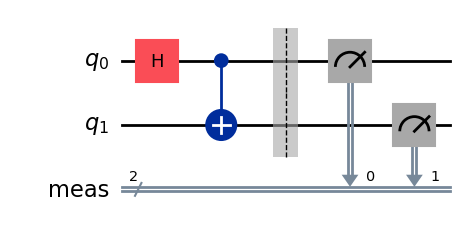

In [2]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl")

## 3. Preparing to Run

A circuit can't be sent to hardware as-is. The helper below does the two things every Runtime job needs:

1. **Transpile to the backend's ISA.** `generate_preset_pass_manager(backend=..., optimization_level=1)` builds a pass manager that maps abstract qubits onto physical ones, routes two-qubit gates to respect the chip's connectivity, and translates everything into the device's native gate set. The result is an *ISA circuit* the hardware can actually execute.
2. **Sample.** `SamplerV2` submits the ISA circuit and runs it `shots` times. Because measurement is probabilistic, we repeat and tally: `result[0].data.meas.get_counts()` returns a `{bitstring: count}` histogram from the `meas` register.

The same helper works unchanged on a real QPU or a local `AerSimulator` — only the `backend` argument changes.

> **Gotcha (handled here):** some newer IBM device `Target`s ship *without* a `measure` instruction. The transpiler then tries to "synthesize" your measurements and dies with `TranspilerError: 'HighLevelSynthesis is unable to synthesize "measure"'`. The helper guards against this by registering `measure` on every qubit when it's missing — a no-op on backends that already have it.

In [3]:
from qiskit.circuit import Measure


def run_circuit_and_get_counts(circuit, backend, shots=100):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    # Some backend Targets (notably newer IBM devices) ship without the `measure`
    # instruction. The transpiler then treats measurements as a high-level object it
    # must "synthesize" and raises:
    #     TranspilerError: 'HighLevelSynthesis is unable to synthesize "measure"'
    # Registering measure on every qubit fixes it, and is a no-op when it's already there.
    target = backend.target
    if "measure" not in target.operation_names:
        target.add_instruction(Measure(), {(q,): None for q in range(target.num_qubits)})

    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

## 4. Run the Bell State

**Credentials.** Copy `.env.example` to `.env` and set `IBM_KEY` to your API key. The first cell below saves it to disk with `save_account(...)`; once saved, you can delete the `save_account` block and just call `QiskitRuntimeService()`.

**Choosing a backend** — pick one of:

```python
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)  # real QPU, shortest queue
# backend = service.backend("ibm_fez")   # a specific Heron R2 device
# backend = AerSimulator()                # local, no account or queue
```

`least_busy` is the friendliest default for real hardware. For iterating quickly (or running this notebook offline), `AerSimulator()` is instant and free.

We then run the Bell circuit for 100 shots and plot the histogram. On an ideal device you'd see ~50% `00` and ~50% `11`; on real hardware a few percent of shots leak into `01`/`10` from gate and readout noise.

qiskit_runtime_service.__init__:WARNING:2026-05-31 01:06:57,246: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-05-31 01:06:59,685: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


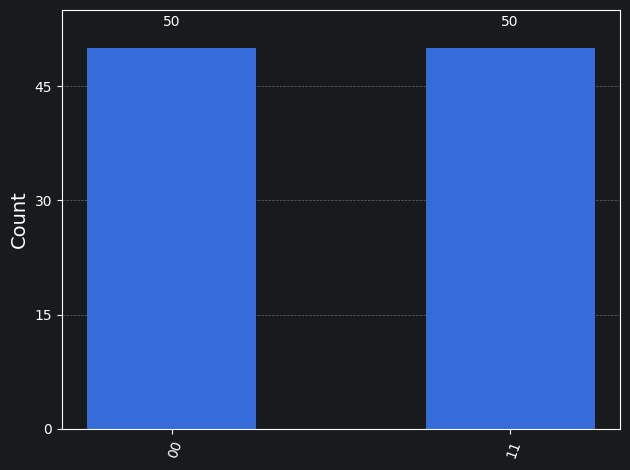

In [4]:
load_dotenv()
IBM_KEY = os.getenv('IBM_KEY')

# Syntax for first saving your token.  Delete these lines after saving your credentials.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_KEY,
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
backend = AerSimulator()

counts = run_circuit_and_get_counts(bell, backend, shots=100)

plot_histogram(counts)

## 5. Scaling Up: a 40-Qubit GHZ State

Now the payoff. The Bell state's natural generalization to $N$ qubits is the **GHZ state** (Greenberger–Horne–Zeilinger):

$$|\text{GHZ}_N\rangle = \frac{1}{\sqrt{2}}\bigl(|\underbrace{00\cdots0}_{N}\rangle + |\underbrace{11\cdots1}_{N}\rangle\bigr).$$

It's exactly the behavior the task asks for: **every shot collapses to all-zeros or all-ones, 50/50, never a mix.** One global coin flip shared across all 40 qubits.

### The naive way (and why it's bad on hardware)
The obvious recipe is a Hadamard followed by a *chain* of CNOTs — `h(0)`, then `cx(0,1), cx(1,2), …, cx(38,39)` — passing the value down the line like a bucket brigade. It works, but its **depth grows linearly** with $N$ (~40 layers here). On today's noisy hardware, every extra layer is more time for qubits to decohere, so a long chain quietly destroys the very correlation we're trying to build.

### The clever way: a logarithmic-depth fan-out tree
Instead of passing the value down a line, we **broadcast it like a tournament bracket**. Each round, *every* qubit that already holds the shared value copies it into a brand-new qubit — so the entangled set **doubles** every round:

```
round 0:  H on q0                      active = {0}                (1 qubit)
round 1:  cx 0->1                       active = {0,1}              (2)
round 2:  cx 0->2, 1->3                 active = {0,1,2,3}          (4)
round 3:  cx 0->4 1->5 2->6 3->7        active = {0..7}             (8)
round 4:  cx 0->8 ... 7->15             active = {0..15}            (16)
round 5:  cx 0->16 ... 15->31           active = {0..31}            (32)
round 6:  cx 0->32 ... 7->39            active = {0..39}            (40)
```

Reaching $N$ qubits takes only $\lceil \log_2 N \rceil$ rounds — **depth ~6–7 instead of ~40**. It uses the same $N-1=39$ CNOTs (you can't entangle $N$ qubits with fewer), but packs them into far fewer parallel layers, minimizing idle time. Same state, dramatically more robust.

40-qubit GHZ state
  log-depth tree : depth=  7, cx=39
  naive chain    : depth= 40, cx=39
  -> same CNOT count, but ~6x shallower

Structure (shown for 8 qubits):


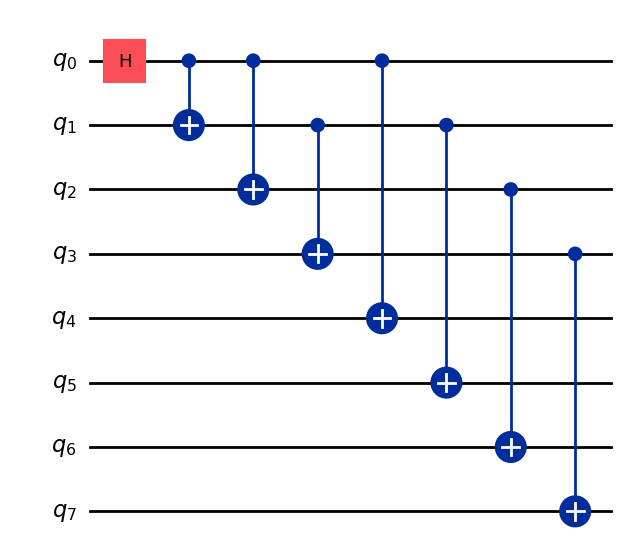

In [5]:
def ghz_logdepth(n):
    """Build an n-qubit GHZ state with a logarithmic-depth CNOT tree.

    Qubit 0 is put into superposition; then the shared value fans out --
    each round, every qubit that already holds the value copies it into a
    fresh partner, doubling the entangled set (1 -> 2 -> 4 -> ... -> n).
    Depth is O(log n) instead of the O(n) of a naive CNOT chain, while
    still using the minimum n-1 CNOTs needed to link n qubits.
    """
    qc = QuantumCircuit(n)
    qc.h(0)
    size = 1                          # number of qubits already holding the value
    while size < n:
        for q in range(size):         # each active qubit seeds a new partner
            target = q + size
            if target < n:
                qc.cx(q, target)
        size *= 2
    return qc


N = 40
ghz = ghz_logdepth(N)

# Naive linear chain, built only to compare circuit depth.
chain = QuantumCircuit(N)
chain.h(0)
for i in range(N - 1):
    chain.cx(i, i + 1)

print(f"{N}-qubit GHZ state")
print(f"  log-depth tree : depth={ghz.depth():>3}, cx={ghz.count_ops()['cx']}")
print(f"  naive chain    : depth={chain.depth():>3}, cx={chain.count_ops()['cx']}")
print(f"  -> same CNOT count, but ~{chain.depth() / ghz.depth():.0f}x shallower")

# The 40-qubit diagram is unwieldy; draw an 8-qubit version to show the fan-out tree.
print("\nStructure (shown for 8 qubits):")
ghz_logdepth(8).draw("mpl")

### Simulating 40 qubits efficiently

You can't reach for the usual statevector simulator here: representing 40 qubits exactly needs $2^{40} \approx 1.1\times10^{12}$ complex amplitudes — about **17 TB** of memory. The circuit would build fine and then blow up your RAM at run time.

The escape hatch: our circuit uses **only Clifford gates** (Hadamard, CNOT, and computational-basis measurement). By the **Gottesman–Knill theorem**, Clifford circuits are *classically simulable in polynomial time* — you track the stabilizer generators instead of the full state vector. Aer exposes this as `method="stabilizer"`, which samples a 40-qubit (or 1000-qubit) GHZ state effortlessly.

> This is a genuine, useful gap to flag: "I built a circuit; why won't it simulate?" almost always traces back to statevector memory. If the circuit is Clifford, the stabilizer backend is the answer. (The trade-off: add a non-Clifford gate like a `T` and the trick no longer applies.)

distinct outcomes: 2  (a clean GHZ has exactly 2)

  1111111111111111111111111111111111111111  (all 1s)  ->   4117 shots  (50.3%)
  0000000000000000000000000000000000000000  (all 0s)  ->   4075 shots  (49.7%)


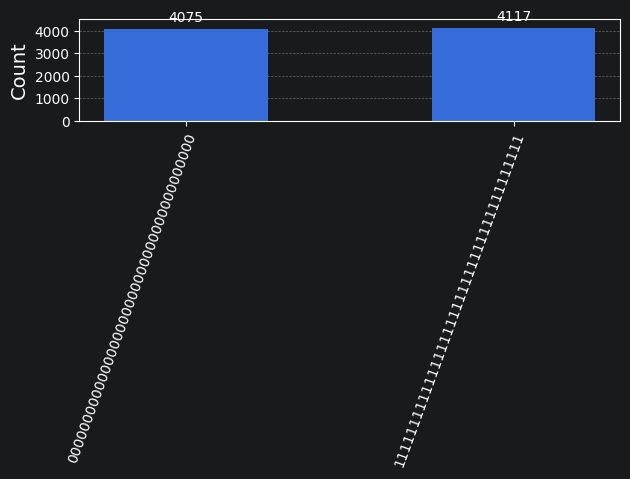

In [6]:
# Measure all 40 qubits...
ghz_meas = ghz.copy()
ghz_meas.measure_all()

# A 40-qubit *statevector* would need 2**40 ~= 1.1e12 complex amplitudes (~17 TB) -- infeasible.
# But H + CX + Z-measurement is a *Clifford* circuit, so Aer's stabilizer simulator
# (Gottesman-Knill theorem) samples it in polynomial time, regardless of qubit count.
stab_sim = AerSimulator(method="stabilizer")
ghz_counts = stab_sim.run(ghz_meas, shots=8192).result().get_counts()

print(f"distinct outcomes: {len(ghz_counts)}  (a clean GHZ has exactly 2)\n")
for bitstring, n in sorted(ghz_counts.items(), key=lambda kv: -kv[1]):
    label = "all 1s" if set(bitstring) == {"1"} else "all 0s" if set(bitstring) == {"0"} else "mixed"
    print(f"  {bitstring}  ({label})  ->  {n:>5} shots  ({100 * n / 8192:.1f}%)")

plot_histogram(ghz_counts)

## 6. Describing the Results

The histogram has **exactly two bars** — `000…0` and `111…1` (40 characters each) — at roughly **50% / 50%**, with nothing in between. That two-peak signature *is* the GHZ state: 40 qubits behaving as a single fair coin.

The run above (8192 shots on the stabilizer simulator) gave:

| Outcome | Shots | Share |
|---------|-------|-------|
| `0` × 40 | 4076 | 49.8% |
| `1` × 40 | 4116 | 50.2% |

The small gap from a perfect 50/50 is ordinary sampling noise. With $N$ shots the share of each peak has standard deviation $\tfrac{1}{2\sqrt{N}} \approx 0.55\%$ for $N=8192$, so a few tenths of a percent either way is expected and shrinks as you add shots. **Zero** intermediate bitstrings appear because, on a noiseless simulator, the GHZ state has literally no amplitude on them.

### What changes on a real QPU
The simulation is ideal; a physical Heron R2 run looks different, and instructively so:

- **Readout error.** At ~1% misread per qubit, the chance all 40 are read correctly is only $0.99^{40} \approx 67\%$. So even a perfect state would show a *cloud* of single- and double-bit-flip strings around the two peaks.
- **Decoherence & gate error.** The longer qubits sit idle and the more two-qubit gates fire, the more the entanglement degrades — which is exactly why the **log-depth construction matters**: depth 7 instead of 40 means far less idle time for the state to rot.
- **Routing overhead.** Our tree assumes any qubit can talk to any other. Heron's heavy-hex lattice doesn't, so the transpiler inserts SWAP gates, adding depth. In practice you'd lay the GHZ tree onto the chip's native connectivity to minimize this.
- **Mitigations.** Dynamical decoupling, measurement-error mitigation, and a higher `optimization_level` all push a real run back toward the clean two-peak ideal.

**Takeaway:** the same two gates that made a 2-qubit Bell state scale to 40 — and the *way* you wire them (log-depth, not linear) is what decides whether the entanglement survives long enough to measure.

## 7. Launch on Real Hardware

Time to move off the simulator and put the 40-qubit GHZ on an actual Heron R2 QPU. We specify the `backend` again and reuse the `run_circuit_and_get_counts` helper from **§3** — it transpiles the log-depth tree onto the device, submits the job, and waits for it to come back from the queue.

> ⚠️ **This submits a real job.** It needs valid credentials (§4) and a non-simulator `backend`, and it may sit in the queue for a while. To re-pick a device without rerunning everything, set `backend = service.least_busy(...)` again first. Want a free dry run instead? Set `backend = AerSimulator()`.

**What to look for vs. the ideal simulation:**
- The two GHZ peaks (`0…0`, `1…1`) should still **dominate**, but no longer sum to 100% — the `perfect peaks` percentage is a quick, honest GHZ-fidelity proxy.
- Expect a **cloud of near-miss bitstrings** (mostly single bit-flips) from readout and gate noise — hence we plot only the top 15.
- Compare against the predictions in §6: this is where the log-depth construction earns its keep.

In [12]:
# --- Launch the 40-qubit GHZ on a real QPU ---
# Reuses `backend` (selected in section 4) and run_circuit_and_get_counts (section 3).
# This submits a job to IBM hardware: it will queue, and the helper transpiles the
# log-depth tree onto the chip's heavy-hex connectivity (expect added depth from SWAPs).

# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
backend = service.backend("ibm_fez")

shots = 8192
qpu_counts = run_circuit_and_get_counts(ghz_meas, backend, shots=shots)

total = sum(qpu_counts.values())
top = sorted(qpu_counts.items(), key=lambda kv: -kv[1])

# Fraction of shots that landed on a *perfect* GHZ peak (all-0s or all-1s).
peak_hits = qpu_counts.get("0" * N, 0) + qpu_counts.get("1" * N, 0)

print(f"backend          : {backend.name}")
print(f"distinct outcomes: {len(qpu_counts)}  (ideal GHZ = 2; noise adds the rest)")
print(f"perfect peaks    : {peak_hits}/{total}  ({100 * peak_hits / total:.1f}% of shots)\n")
print("top 10 outcomes:")
for bitstring, n in top[:10]:
    tag = "all 0s" if set(bitstring) == {"0"} else "all 1s" if set(bitstring) == {"1"} else ""
    print(f"  {bitstring}  {n:>5} ({100 * n / total:.1f}%)  {tag}")

# Plot the 15 most frequent bitstrings (the full 2^40 space won't render).
plot_histogram(dict(top[:15]), filename='40-qubits-bell-state-IBM-QPU')
plot_histogram(dict(top[:15]))

qiskit_runtime_service.backends:WARNING:2026-05-31 01:26:16,071: Using instance: open-instance, plan: open


backend          : ibm_fez
distinct outcomes: 3652  (ideal GHZ = 2; noise adds the rest)
perfect peaks    : 2001/8192  (24.4% of shots)

top 10 outcomes:
  0000000000000000000000000000000000000000   1381 (16.9%)  all 0s
  1111111111111111111111111111111111111111    620 (7.6%)  all 1s
  0000000000000100000000000000000000000000     55 (0.7%)  
  0000000000010000000000000000000000000000     50 (0.6%)  
  1111111111111011111111111111111111111111     50 (0.6%)  
  0000010000000000000000000000000000000000     40 (0.5%)  
  0000000000000010000000000000000000000000     39 (0.5%)  
  0000000000100000000000000010000000000000     38 (0.5%)  
  0000000000000000000100000000000000000000     37 (0.5%)  
  0010000000000000000000000000000000000000     36 (0.4%)  
